# PK-PD Elimination Equation: Paper Plots

This notebook generates plots for the paper, focusing on specific drugs.

**Equation:**
```
R(C₀, t) = R₀ + Emax * (1 - exp(-κ * (C₀/Cmax * exp(-k_elim * t))^n * (t/τ)^m))
```

**Features:**
- Loads PK-PD Elimination coefficients from Excel
- Filters to specific drugs for individual plots
- Shows preview plots of all drugs in categories
- Generates 2D plots for specific drugs
- Saves all plots at the end

**Specific Drugs:**
- Chloropromazine, cobimetinib, epirubicin, vandetanib, Sunitinib, panobinostat, Dactinomycin, Erlotinib, Etomoxir, Plicamycin, Daunorubicin, Doxorubicin


## 1. Setup & Imports

In [1]:
# Cell 1
# Dependencies: None
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Find project root - look for EQN_Coefficients directory (current workspace structure)
current_dir = Path.cwd()

# Strategy 1: Check if we're in Prediction_Models directory
if current_dir.name == 'Prediction_Models':
    PROJECT_ROOT = current_dir.parent
# Strategy 2: Check if EQN_Coefficients exists in current directory
elif (current_dir / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir
# Strategy 3: Check if EQN_Coefficients exists one level up
elif (current_dir.parent / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir.parent
# Strategy 4: Check if we're in a subdirectory and need to go up
elif (current_dir.parent.parent / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir.parent.parent
else:
    # Default: assume current directory is project root
    PROJECT_ROOT = current_dir

# Define paths
EXCEL_PATH = PROJECT_ROOT / 'EQN_Coefficients' / 'all_equations_coefficients.xlsx'
OUTPUT_DIR = PROJECT_ROOT / 'Output' / '3D_Plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"Project root: {PROJECT_ROOT}")
print(f"Excel path: {EXCEL_PATH}")
print(f"Excel file exists: {EXCEL_PATH.exists()}")
print(f"Output directory: {OUTPUT_DIR}")


Setup complete!
Project root: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO
Excel path: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\EQN_Coefficients\all_equations_coefficients.xlsx
Excel file exists: True
Output directory: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\3D_Plots


## 2. Data Loading

In [2]:
# Cell 2
# Dependencies: 1
print("="*80)
print("LOADING PK-PD ELIMINATION DATA")
print("="*80)

# Load data from Excel (skip first header row)
df_raw = pd.read_excel(EXCEL_PATH, sheet_name='pkpd_elimination', header=1)

# Clean column names
df_raw.columns = df_raw.columns.str.strip()

# Remove rows with missing Drug names
df_raw = df_raw[df_raw['Drug'].notna() & (df_raw['Drug'].astype(str).str.strip() != '')]

print(f"\nLoaded data: {len(df_raw)} drugs")
print(f"Columns: {len(df_raw.columns)}")
print(f"\nColumn names:")
print(df_raw.columns.tolist())


LOADING PK-PD ELIMINATION DATA

Loaded data: 25 drugs
Columns: 24

Column names:
['Drug', 'Arrhythmia', 'heart_damage', 'Concern', 'R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim', 'Cmax_used', 'R2', 'N_points', 'R0.1', 'Emax.1', 'kappa.1', 'n.1', 'm.1', 'tau.1', 'k_elim.1', 'Cmax_used.1', 'R2.1', 'N_points.1']


In [4]:
# Cell 3
# Dependencies: 1, 2
# Optional: Filter to specific drugs for focused analysis

specific_drugs = []  # leave empty to include all drugs

print("OPTIONAL FILTERING TO SPECIFIC DRUGS")
print("="*80)

def normalize_name(s):
    """Normalize drug name for matching"""
    if pd.isna(s):
        return ''
    return str(s).lower().replace(' ', '').replace('(', '').replace(')', '')

original_count = len(df_raw)

if specific_drugs:
    df_raw = df_raw[
        df_raw['Drug'].apply(lambda x: normalize_name(str(x)) in [normalize_name(d) for d in specific_drugs])
    ].copy()
    print(f"Filtered data: {len(df_raw)} drugs out of {original_count} total")
    if len(df_raw) > 0:
        print(f"Filtered drugs: {', '.join(df_raw['Drug'].astype(str).tolist())}")
else:
    print(f"No specific drugs provided. Using all {original_count} drugs.")


OPTIONAL FILTERING TO SPECIFIC DRUGS
No specific drugs provided. Using all 25 drugs.


## 3. Function Definitions

### 3.1 Core Analysis Functions

In [5]:
# Cell 4
# Dependencies: 1, 2
print("="*80)
print("EXTRACTING COEFFICIENTS")
print("="*80)

# Define parameter names BEFORE using them in the function
param_names = ['R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim']

# Function to extract coefficients for a response type
def extract_coefficients(df, response_type):
    """
    Extract coefficients for Contractility or O2 response type.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Raw data with coefficients
    response_type : str
        'Contractility' or 'O2'
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with extracted coefficients and metadata
    """
    # Base columns to keep (only include columns that exist)
    base_cols = ['Drug', 'Arrhythmia', 'heart_damage', 'Concern']
    # Add DrugKey if it exists (it's optional, used for filtering)
    if 'DrugKey' in df.columns:
        base_cols.append('DrugKey')
    
    if response_type == 'Contractility':
        # Use first set of parameters (no suffix)
        param_cols = param_names.copy()
    else:  # O2
        # Use parameters with .1 suffix (Excel auto-renaming)
        param_cols = [f'{p}.1' if f'{p}.1' in df.columns else f'{p}_1' for p in param_names]
    
    # Check which columns exist
    available_cols = []
    for col in param_cols:
        if col in df.columns:
            available_cols.append(col)
        else:
            # Try alternative naming
            alt_cols = [c for c in df.columns if c.startswith(col.split('.')[0])]
            if alt_cols:
                available_cols.append(alt_cols[-1])  # Use last match (should be O2)
            else:
                print(f"Warning: Could not find column for {col}")
    
    # Get Cmax column
    cmax_col = None
    for cand in ['Cmax_used', 'Cmax_used.1', 'Cmax_phys_uM', 'Cmax_uM', 'Cmax']:
        if cand in df.columns:
            cmax_col = cand
            break
    
    # Create result dataframe
    result = df[base_cols].copy()
    
    # Add parameters with standard names
    for i, param in enumerate(param_names):
        if i < len(available_cols):
            result[param] = df[available_cols[i]]
        else:
            result[param] = np.nan
    
    # Add Cmax
    if cmax_col:
        result['Cmax_used'] = df[cmax_col]
    else:
        result['Cmax_used'] = 1.0
        print("Warning: Cmax column not found, using default Cmax=1.0")
    
    return result

# Extract for both response types
df_contractility = extract_coefficients(df_raw, 'Contractility')
df_o2 = extract_coefficients(df_raw, 'O2')

print(f"\nContractility data: {len(df_contractility)} drugs")
print(f"O2 data: {len(df_o2)} drugs")

# Check for valid coefficients
def count_valid_coefficients(df):
    """Count drugs with valid (finite) coefficients"""
    valid = df[param_names].notna().all(axis=1) & df[param_names].apply(lambda x: np.isfinite(x)).all(axis=1)
    return valid.sum()

print(f"\nValid Contractility coefficients: {count_valid_coefficients(df_contractility)}")
print(f"Valid O2 coefficients: {count_valid_coefficients(df_o2)}")

EXTRACTING COEFFICIENTS

Contractility data: 25 drugs
O2 data: 25 drugs

Valid Contractility coefficients: 25
Valid O2 coefficients: 25


In [7]:
# Cell 5
# Dependencies: 1-4
def pkpd_elimination_response(dose_ratio, time, R0, Emax, kappa, n, m, tau, k_elim):
    """
    Calculate PKPD elimination response.
    
    Parameters:
    -----------
    dose_ratio : array-like
        Dose ratio (C₀/Cmax), typically 0 to 2
    time : array-like
        Time (hours), typically 0 to 96
    R0 : float
        Baseline response
    Emax : float
        Maximum effect amplitude
    kappa : float
        Potency parameter
    n : float
        Hill coefficient for concentration
    m : float
        Hill coefficient for time
    tau : float
        Time scale (hours)
    k_elim : float
        Elimination rate constant (1/hours)
        
    Returns:
    --------
    array-like
        Response values R(C₀, t)
    """
    # Ensure arrays are numpy arrays
    dose_ratio = np.asarray(dose_ratio)
    time = np.asarray(time)
    
    # Create meshgrid if inputs are 1D
    if dose_ratio.ndim == 1 and time.ndim == 1:
        dose_ratio, time = np.meshgrid(dose_ratio, time)
    
    # Ensure positive values to avoid numerical issues
    kappa = max(kappa, 1e-9)
    tau = max(tau, 1e-9)
    k_elim = max(k_elim, 1e-9)
    time = np.maximum(time, 1e-9)
    
    # Concentration decays over time: C(t)/Cmax = (C₀/Cmax) * exp(-k_elim * t)
    C_norm = dose_ratio * np.exp(-k_elim * time)
    
    # Time component: (t/τ)^m
    time_component = (time / tau) ** m
    
    # Concentration component: (C_norm)^n
    conc_component = C_norm ** n
    
    # Combined: κ * (C_norm)^n * (t/τ)^m
    combined = kappa * conc_component * time_component
    
    # Full equation: R = R₀ + Emax * (1 - exp(-combined))
    response = R0 + Emax * (1 - np.exp(-combined))
    
    return response

print("PK-PD Elimination equation function defined!")


PK-PD Elimination equation function defined!


### 3.2 Plotting Functions

In [8]:
# Cell 6
# Dependencies: Cells 1-5 (imports, data, core functions)

import math

def round_up_to_nice_value(value):
    """Round up to nearest nice value (10, 20, 50, 100, etc.)"""
    if value <= 0:
        return 1

    magnitude = 10 ** math.floor(math.log10(value))
    normalized = value / magnitude

    if normalized <= 1:
        nice = 1
    elif normalized <= 2:
        nice = 2
    elif normalized <= 5:
        nice = 5
    else:
        nice = 10

    return nice * magnitude

def calculate_global_response_range(df, response_type, remove_r0_offset=False):
    """
    Calculate global min/max response values across all drugs for consistent scaling.

    Parameters:
    -----------
    df : DataFrame
        Drug coefficient data
    response_type : str
        'Contractility' or 'O2'
    remove_r0_offset : bool
        If True, calculate actual max after R0 removal and round up nicely
        If False, use fixed ranges (0-0.14 for Contractility, 0-70 for O2)

    Returns:
    --------
    tuple: (vmin, vmax, zmin, zmax) for color and Z-axis scaling
    """
    # Fixed ranges for non-R0-excluded cases
    if not remove_r0_offset:
        if response_type == 'O2':
            return (0, 70, 0, 70)
        else:
            return (0, 0.14, 0, 0.14)

    # Calculate actual range when R0 is excluded
    dose_ratio = np.linspace(0, 2, 60)
    time = np.linspace(0, 96, 60)
    T, Dr = np.meshgrid(time, dose_ratio)

    all_max_values = []
    all_min_values = []

    for idx in df.index:
        row = df.loc[idx]
        R0 = row['R0']
        Emax = row['Emax']
        kappa = row['kappa']
        n = row['n']
        m = row['m']
        tau = row['tau']
        k_elim = row['k_elim']

        if not all(np.isfinite([R0, Emax, kappa, n, m, tau, k_elim])):
            continue

        Response = pkpd_elimination_response(Dr, T, R0, Emax, kappa, n, m, tau, k_elim)
        # Remove R0 offset
        Response_no_r0 = Response - R0

        max_val = np.nanmax(Response_no_r0)
        min_val = np.nanmin(Response_no_r0)

        if np.isfinite(max_val):
            all_max_values.append(max_val)
        if np.isfinite(min_val):
            all_min_values.append(min_val)

    if not all_max_values:
        return (0, 70, 0, 70) if response_type == 'O2' else (0, 0.14, 0, 0.14)

    actual_max = max(all_max_values)
    actual_min = min(all_min_values) if all_min_values else 0

    # Use exact maximum value across all drugs (no rounding, no margin)
    vmax = actual_max

    # For Z-axis, use the same limits
    zmax = vmax
    zmin = 0  # Always start Z from 0

    return (0, vmax, zmin, zmax)

def plot_individual_surface(df, idx, response_type, ax=None, vmin=None, vmax=None,
                           zlim=None, remove_r0_offset=False):
    """
    Plot a single 3D surface for a drug's response.

    Parameters:
    -----------
    df : DataFrame
        Drug coefficient data
    idx : index
        Drug index in DataFrame
    response_type : str
        'Contractility' or 'O2'
    ax : matplotlib axes
        3D axes to plot on
    vmin, vmax : float
        Color scale limits
    zlim : tuple (zmin, zmax)
        Z-axis limits for consistent height across all plots
    remove_r0_offset : bool
        If True, subtract R0 from response values
    """
    row = df.loc[idx]
    drug_name = row.get('Drug', str(idx))

    R0 = row['R0']
    Emax = row['Emax']
    kappa = row['kappa']
    n = row['n']
    m = row['m']
    tau = row['tau']
    k_elim = row['k_elim']

    # Grid for plotting
    dose_ratio = np.linspace(0, 2, 60)
    time = np.linspace(0, 96, 60)
    T, Dr = np.meshgrid(time, dose_ratio)

    Response = pkpd_elimination_response(Dr, T, R0, Emax, kappa, n, m, tau, k_elim)
    if remove_r0_offset:
        Response = Response - R0

    # Create plot
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

    # Color normalization
    if vmin is None or vmax is None:
        vmin_use, vmax_use = 0, np.nanmax(Response)
    else:
        vmin_use, vmax_use = vmin, vmax

    norm = plt.Normalize(vmin=vmin_use, vmax=vmax_use)

    # Plot surface
    surf = ax.plot_surface(T, Dr, Response, cmap='turbo', norm=norm,
                          linewidth=0, antialiased=True, edgecolor='none', alpha=0.8)

    # Set Z-axis limits for uniform height
    if zlim is not None:
        ax.set_zlim(zlim[0], zlim[1])

    # Labels
    ax.set_xlabel('Time (hours)', fontsize=10)
    ax.set_ylabel('Dose Ratio (C0/Cmax)', fontsize=10)
    z_label = f'{response_type} Response'
    if remove_r0_offset:
        z_label += ' (R0 excluded)'
    ax.set_zlabel(z_label, fontsize=10)
    # ax.set_title(f'{drug_name} - {response_type}', fontsize=12, pad=20)  # Title removed for publication

    # Set view angle
    ax.view_init(elev=25, azim=-158)

    # NO COLORBAR - removed as requested

    return ax

print('Plotting functions updated:')
print('  - Removed colorbar from plots')
print('  - Added zlim parameter for uniform Z-axis height')
print('  - calculate_global_response_range() returns (vmin, vmax, zmin, zmax)')


Plotting functions updated:
  - Removed colorbar from plots
  - Added zlim parameter for uniform Z-axis height
  - calculate_global_response_range() returns (vmin, vmax, zmin, zmax)


In [9]:
# Cell 8
# Dependencies: 1-7
def filter_valid_drugs(df):
    """Filter drugs with valid (finite) coefficients"""
    param_cols = ['R0', 'Emax', 'kappa', 'n', 'm', 'tau', 'k_elim']
    valid_mask = df[param_cols].notna().all(axis=1) & df[param_cols].apply(lambda x: np.isfinite(x)).all(axis=1)
    return df[valid_mask].copy()

def group_by_categories(df):
    """
    Group drugs by categories.
    
    Returns:
    --------
    dict
        Dictionary with category groups
    """
    groups = {}
    
    # Convert boolean columns to strings for consistency
    df = df.copy()
    if df['Arrhythmia'].dtype == bool:
        df['Arrhythmia'] = df['Arrhythmia'].map({True: 'True', False: 'False'})
    if df['heart_damage'].dtype == bool:
        df['heart_damage'] = df['heart_damage'].map({True: 'True', False: 'False'})
    
    # Group by Arrhythmia
    groups['Arrhythmia'] = {}
    for val in df['Arrhythmia'].unique():
        if pd.notna(val):
            groups['Arrhythmia'][val] = df[df['Arrhythmia'] == val].index.tolist()
    
    # Group by heart_damage
    groups['heart_damage'] = {}
    for val in df['heart_damage'].unique():
        if pd.notna(val):
            groups['heart_damage'][val] = df[df['heart_damage'] == val].index.tolist()
    
    # Group by Concern
    groups['Concern'] = {}
    for val in df['Concern'].unique():
        if pd.notna(val):
            groups['Concern'][val] = df[df['Concern'] == val].index.tolist()
    
    return groups

# Filter valid drugs
df_contractility_valid = filter_valid_drugs(df_contractility)
df_o2_valid = filter_valid_drugs(df_o2)

print("="*80)
print("VALID DRUGS SUMMARY")
print("="*80)
print(f"\nContractility - Valid: {len(df_contractility_valid)}, Total: {len(df_contractility)}")
print(f"O2 - Valid: {len(df_o2_valid)}, Total: {len(df_o2)}")

# Note: Data was already filtered to specific drugs in Cell 3 before coefficient extraction
# All subsequent analysis will use only the filtered drugs

# Calculate global response ranges for consistent color scaling (using filtered data)
print("\n" + "="*80)
print("CALCULATING GLOBAL RESPONSE RANGES FOR CONSISTENT COLOR SCALING")
print("="*80)
contractility_vmin, contractility_vmax, contractility_zmin, contractility_zmax = calculate_global_response_range(df_contractility_valid, 'Contractility', remove_r0_offset=True)
o2_vmin, o2_vmax, o2_zmin, o2_zmax = calculate_global_response_range(df_o2_valid, 'O2', remove_r0_offset=True)
print(f"\nContractility global range: [{contractility_vmin:.6f}, {contractility_vmax:.6f}]")
print(f"O2 range: Color [{o2_vmin:.6f}, {o2_vmax:.6f}], Z-axis [{o2_zmin:.6f}, {o2_zmax:.6f}]")
print("\nAll plots will use these ranges for consistent color scaling.")

# Group by categories (using filtered data)
contractility_groups = group_by_categories(df_contractility_valid)
o2_groups = group_by_categories(df_o2_valid)

print("\nContractility Categories:")
for cat_type, cat_dict in contractility_groups.items():
    print(f"  {cat_type}:")
    for cat_val, indices in cat_dict.items():
        print(f"    {cat_val}: {len(indices)} drugs")

print("\nO2 Categories:")
for cat_type, cat_dict in o2_groups.items():
    print(f"  {cat_type}:")
    for cat_val, indices in cat_dict.items():
        print(f"    {cat_val}: {len(indices)} drugs")


VALID DRUGS SUMMARY

Contractility - Valid: 25, Total: 25
O2 - Valid: 25, Total: 25

CALCULATING GLOBAL RESPONSE RANGES FOR CONSISTENT COLOR SCALING

Contractility global range: [0.000000, 0.069110]
O2 range: Color [0.000000, 50.256406], Z-axis [0.000000, 50.256406]

All plots will use these ranges for consistent color scaling.

Contractility Categories:
  Arrhythmia:
    True: 14 drugs
    False: 11 drugs
  heart_damage:
    True: 20 drugs
    False: 5 drugs
  Concern:
    most: 15 drugs
    less: 6 drugs
    no: 4 drugs

O2 Categories:
  Arrhythmia:
    True: 14 drugs
    False: 11 drugs
  heart_damage:
    True: 20 drugs
    False: 5 drugs
  Concern:
    most: 15 drugs
    less: 6 drugs
    no: 4 drugs


### 3.3 5x5 Grid Definitions

O2 colorbar: [0 to 51]
  Ticks: [np.int64(0), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50)]


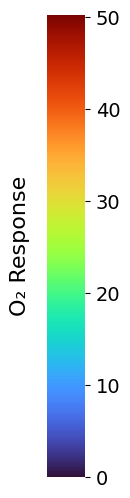

Contractility colorbar: [0 to 0.07]
  Ticks: [np.float64(0.0), np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.04), np.float64(0.05), np.float64(0.06), np.float64(0.07)]


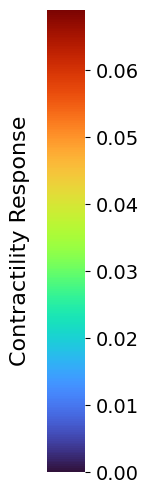

Colorbars with complete tick range (0 to max included)


In [10]:
# Cell 9
# Dependencies: 1-7, 8 (for scale values)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# O2 colorbar - EXACT same setup as plots
o2_norm = Normalize(vmin=0, vmax=o2_vmax)

fig_o2, ax_o2 = plt.subplots(figsize=(0.5, 6), facecolor='none')
sm_o2 = ScalarMappable(norm=o2_norm, cmap='turbo')
sm_o2.set_array([])

# Round max to whole number
o2_max_rounded = int(np.ceil(o2_vmax))

# Generate tick step based on range
if o2_max_rounded > 50:
    tick_step = 10
elif o2_max_rounded > 20:
    tick_step = 5
else:
    tick_step = 2

# Generate ticks including 0 and max
o2_ticks = np.arange(0, o2_max_rounded + 1, tick_step)

cbar_o2 = plt.colorbar(sm_o2, cax=ax_o2, orientation='vertical', ticks=o2_ticks)
cbar_o2.ax.yaxis.set_label_position('left')
cbar_o2.set_label('O₂ Response', fontsize=16, labelpad=12)
cbar_o2.ax.tick_params(labelsize=14, pad=4)
cbar_o2.outline.set_visible(False)
fig_o2.patch.set_alpha(0)

plt.savefig('Output/2D_Plots/O2_colorbar_custom.png', bbox_inches='tight',
            transparent=True, dpi=300)
print(f'O2 colorbar: [0 to {o2_max_rounded}]')
print(f'  Ticks: {list(o2_ticks)}')
plt.show()

# Contractility colorbar - EXACT same setup as plots
con_norm = Normalize(vmin=0, vmax=contractility_vmax)

fig_con, ax_con = plt.subplots(figsize=(0.5, 6), facecolor='none')
sm_con = ScalarMappable(norm=con_norm, cmap='turbo')
sm_con.set_array([])

# Round max to hundredth
con_max_rounded = np.ceil(contractility_vmax * 100) / 100

# Generate tick step
if con_max_rounded > 0.1:
    tick_step = 0.02
elif con_max_rounded > 0.05:
    tick_step = 0.01
else:
    tick_step = 0.005

# Generate ticks including 0 and max, ensuring max is included
con_ticks = np.arange(0, con_max_rounded + tick_step/2, tick_step)
# Round to avoid floating point issues
con_ticks = np.round(con_ticks, 3)

cbar_con = plt.colorbar(sm_con, cax=ax_con, orientation='vertical', ticks=con_ticks)
cbar_con.ax.yaxis.set_label_position('left')
cbar_con.set_label('Contractility Response', fontsize=16, labelpad=12)
cbar_con.ax.tick_params(labelsize=14, pad=4)
cbar_con.outline.set_visible(False)
fig_con.patch.set_alpha(0)

plt.savefig('Output/2D_Plots/Contractility_Colorbar_Scale.png', bbox_inches='tight',
            transparent=True, dpi=300)
print(f'Contractility colorbar: [0 to {con_max_rounded:.2f}]')
print(f'  Ticks: {list(con_ticks)}')
plt.show()

print('Colorbars with complete tick range (0 to max included)')


Displaying 5x5 grids with GLOBAL color normalization...
O2 color scale: [0, 50.26]
Contractility color scale: [0, 0.0691]
Creating O2 grid...


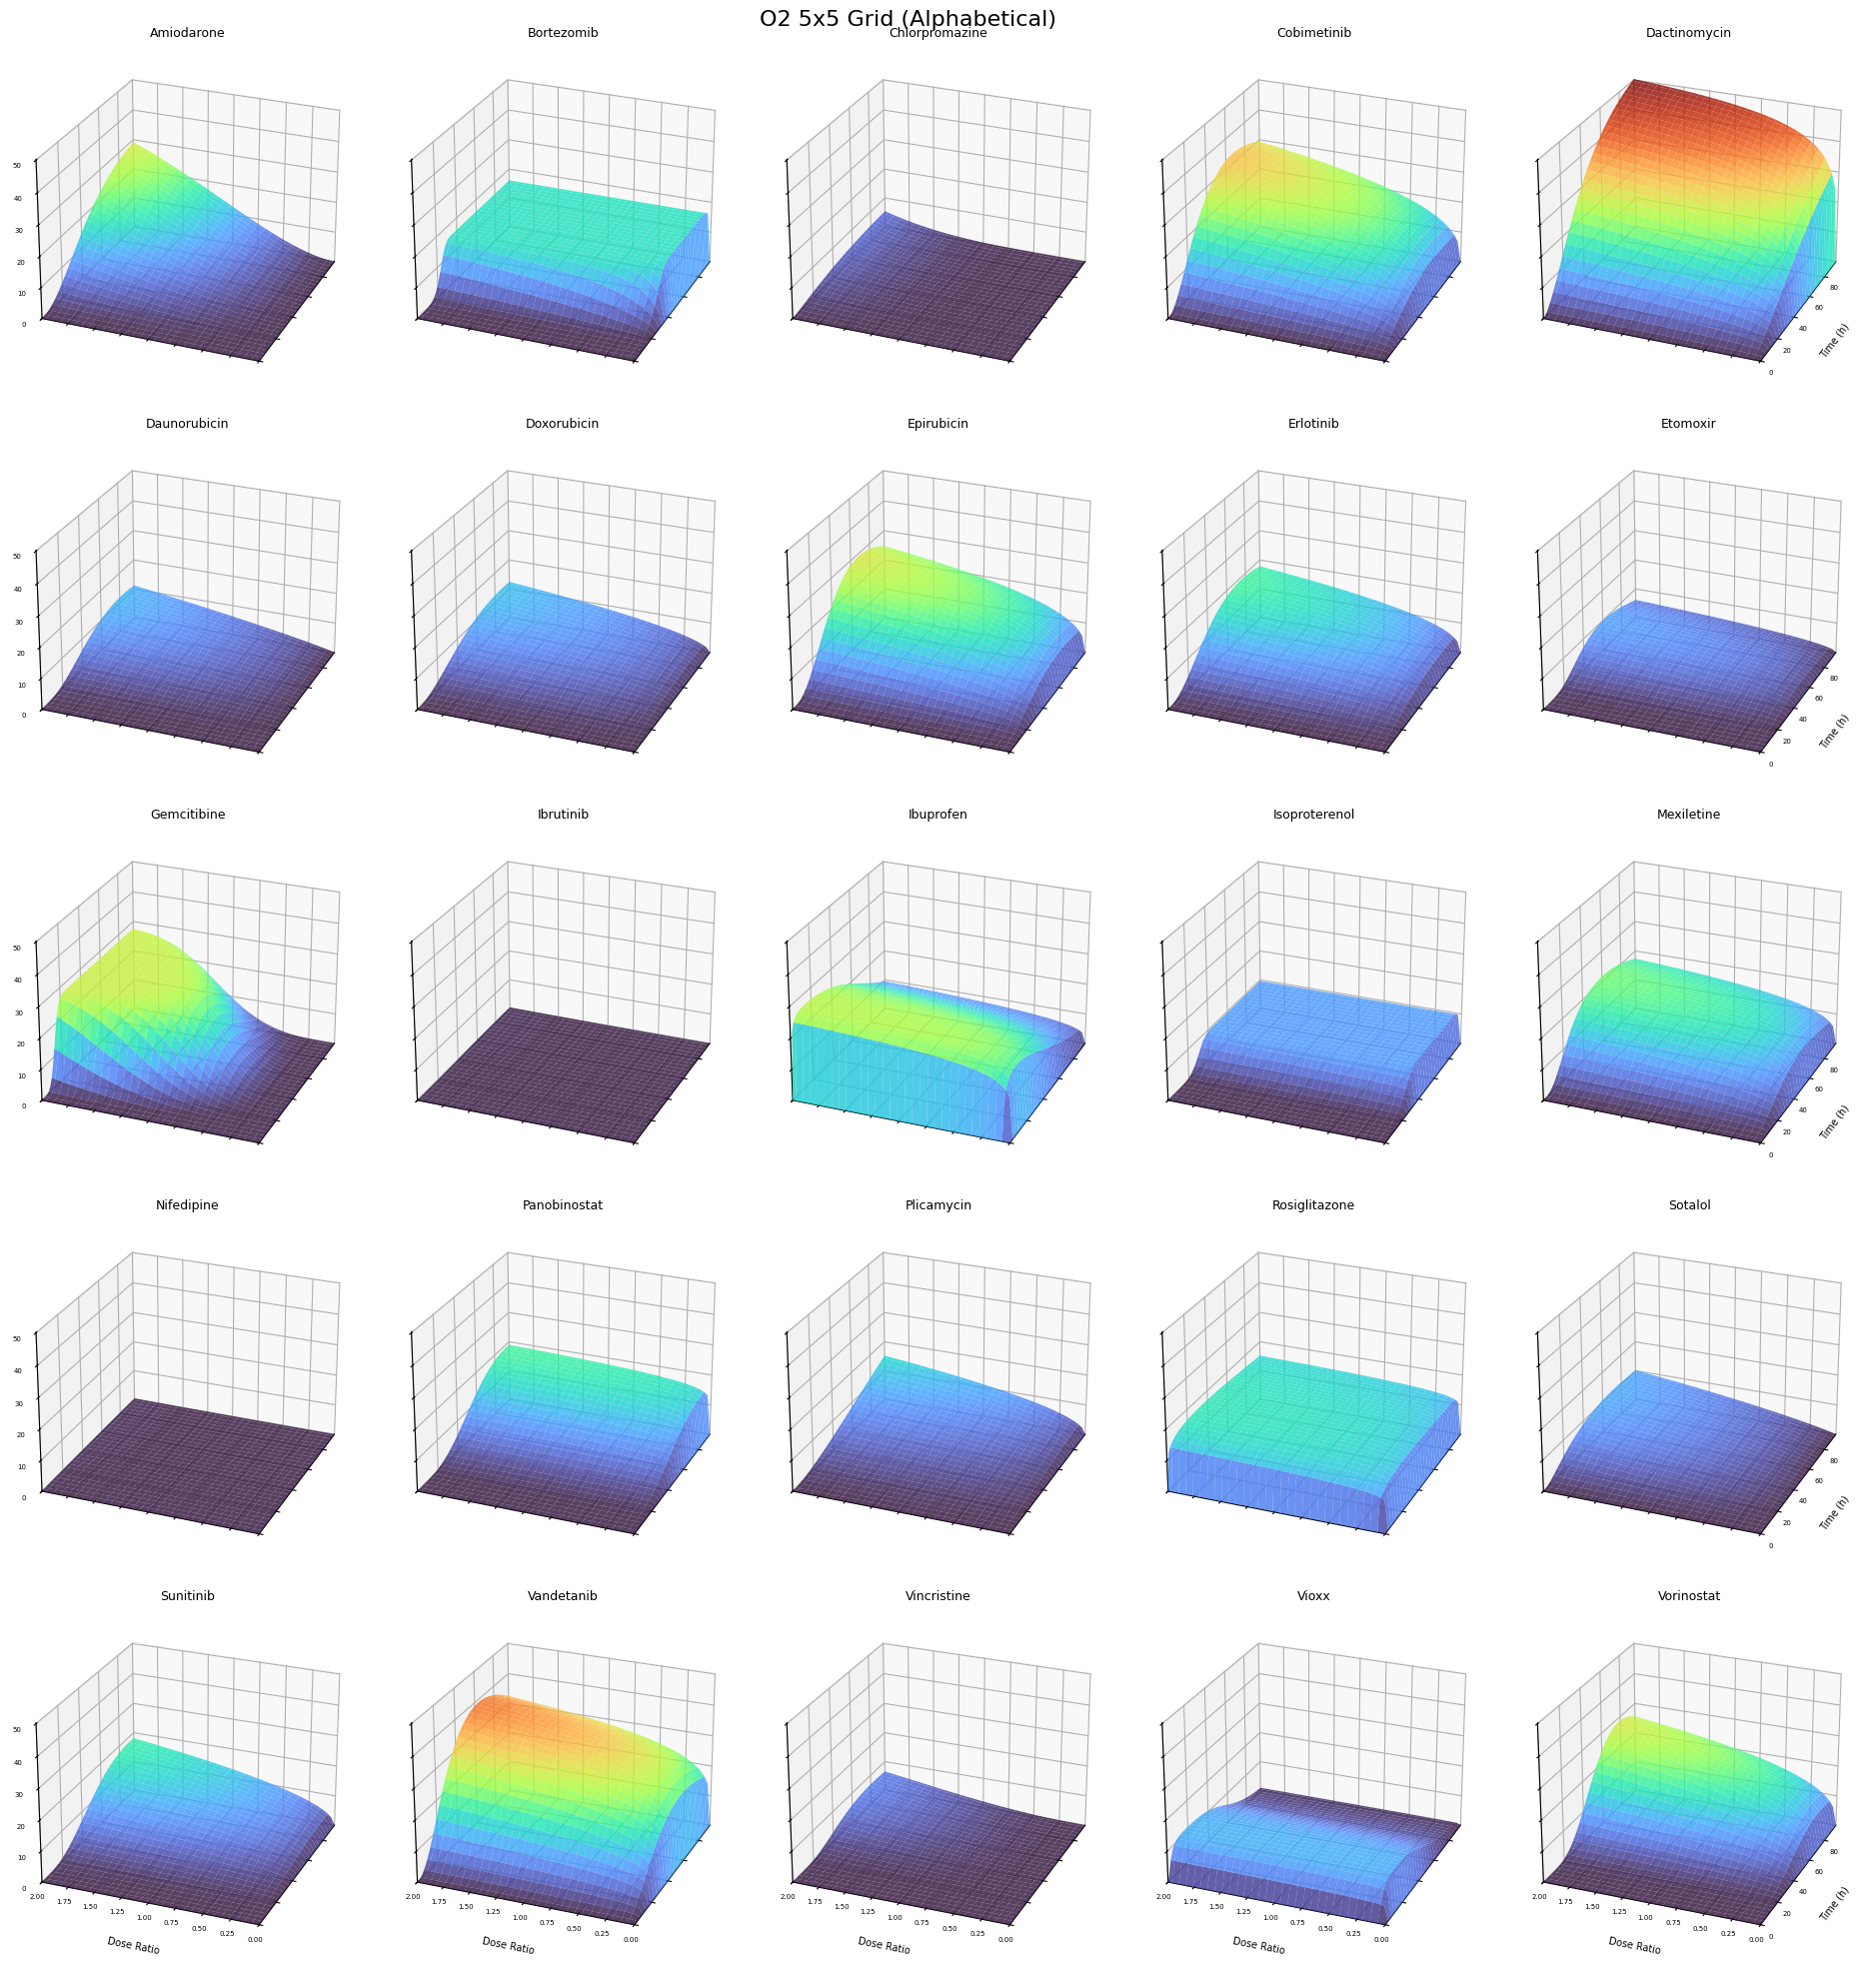

Creating Contractility grid...


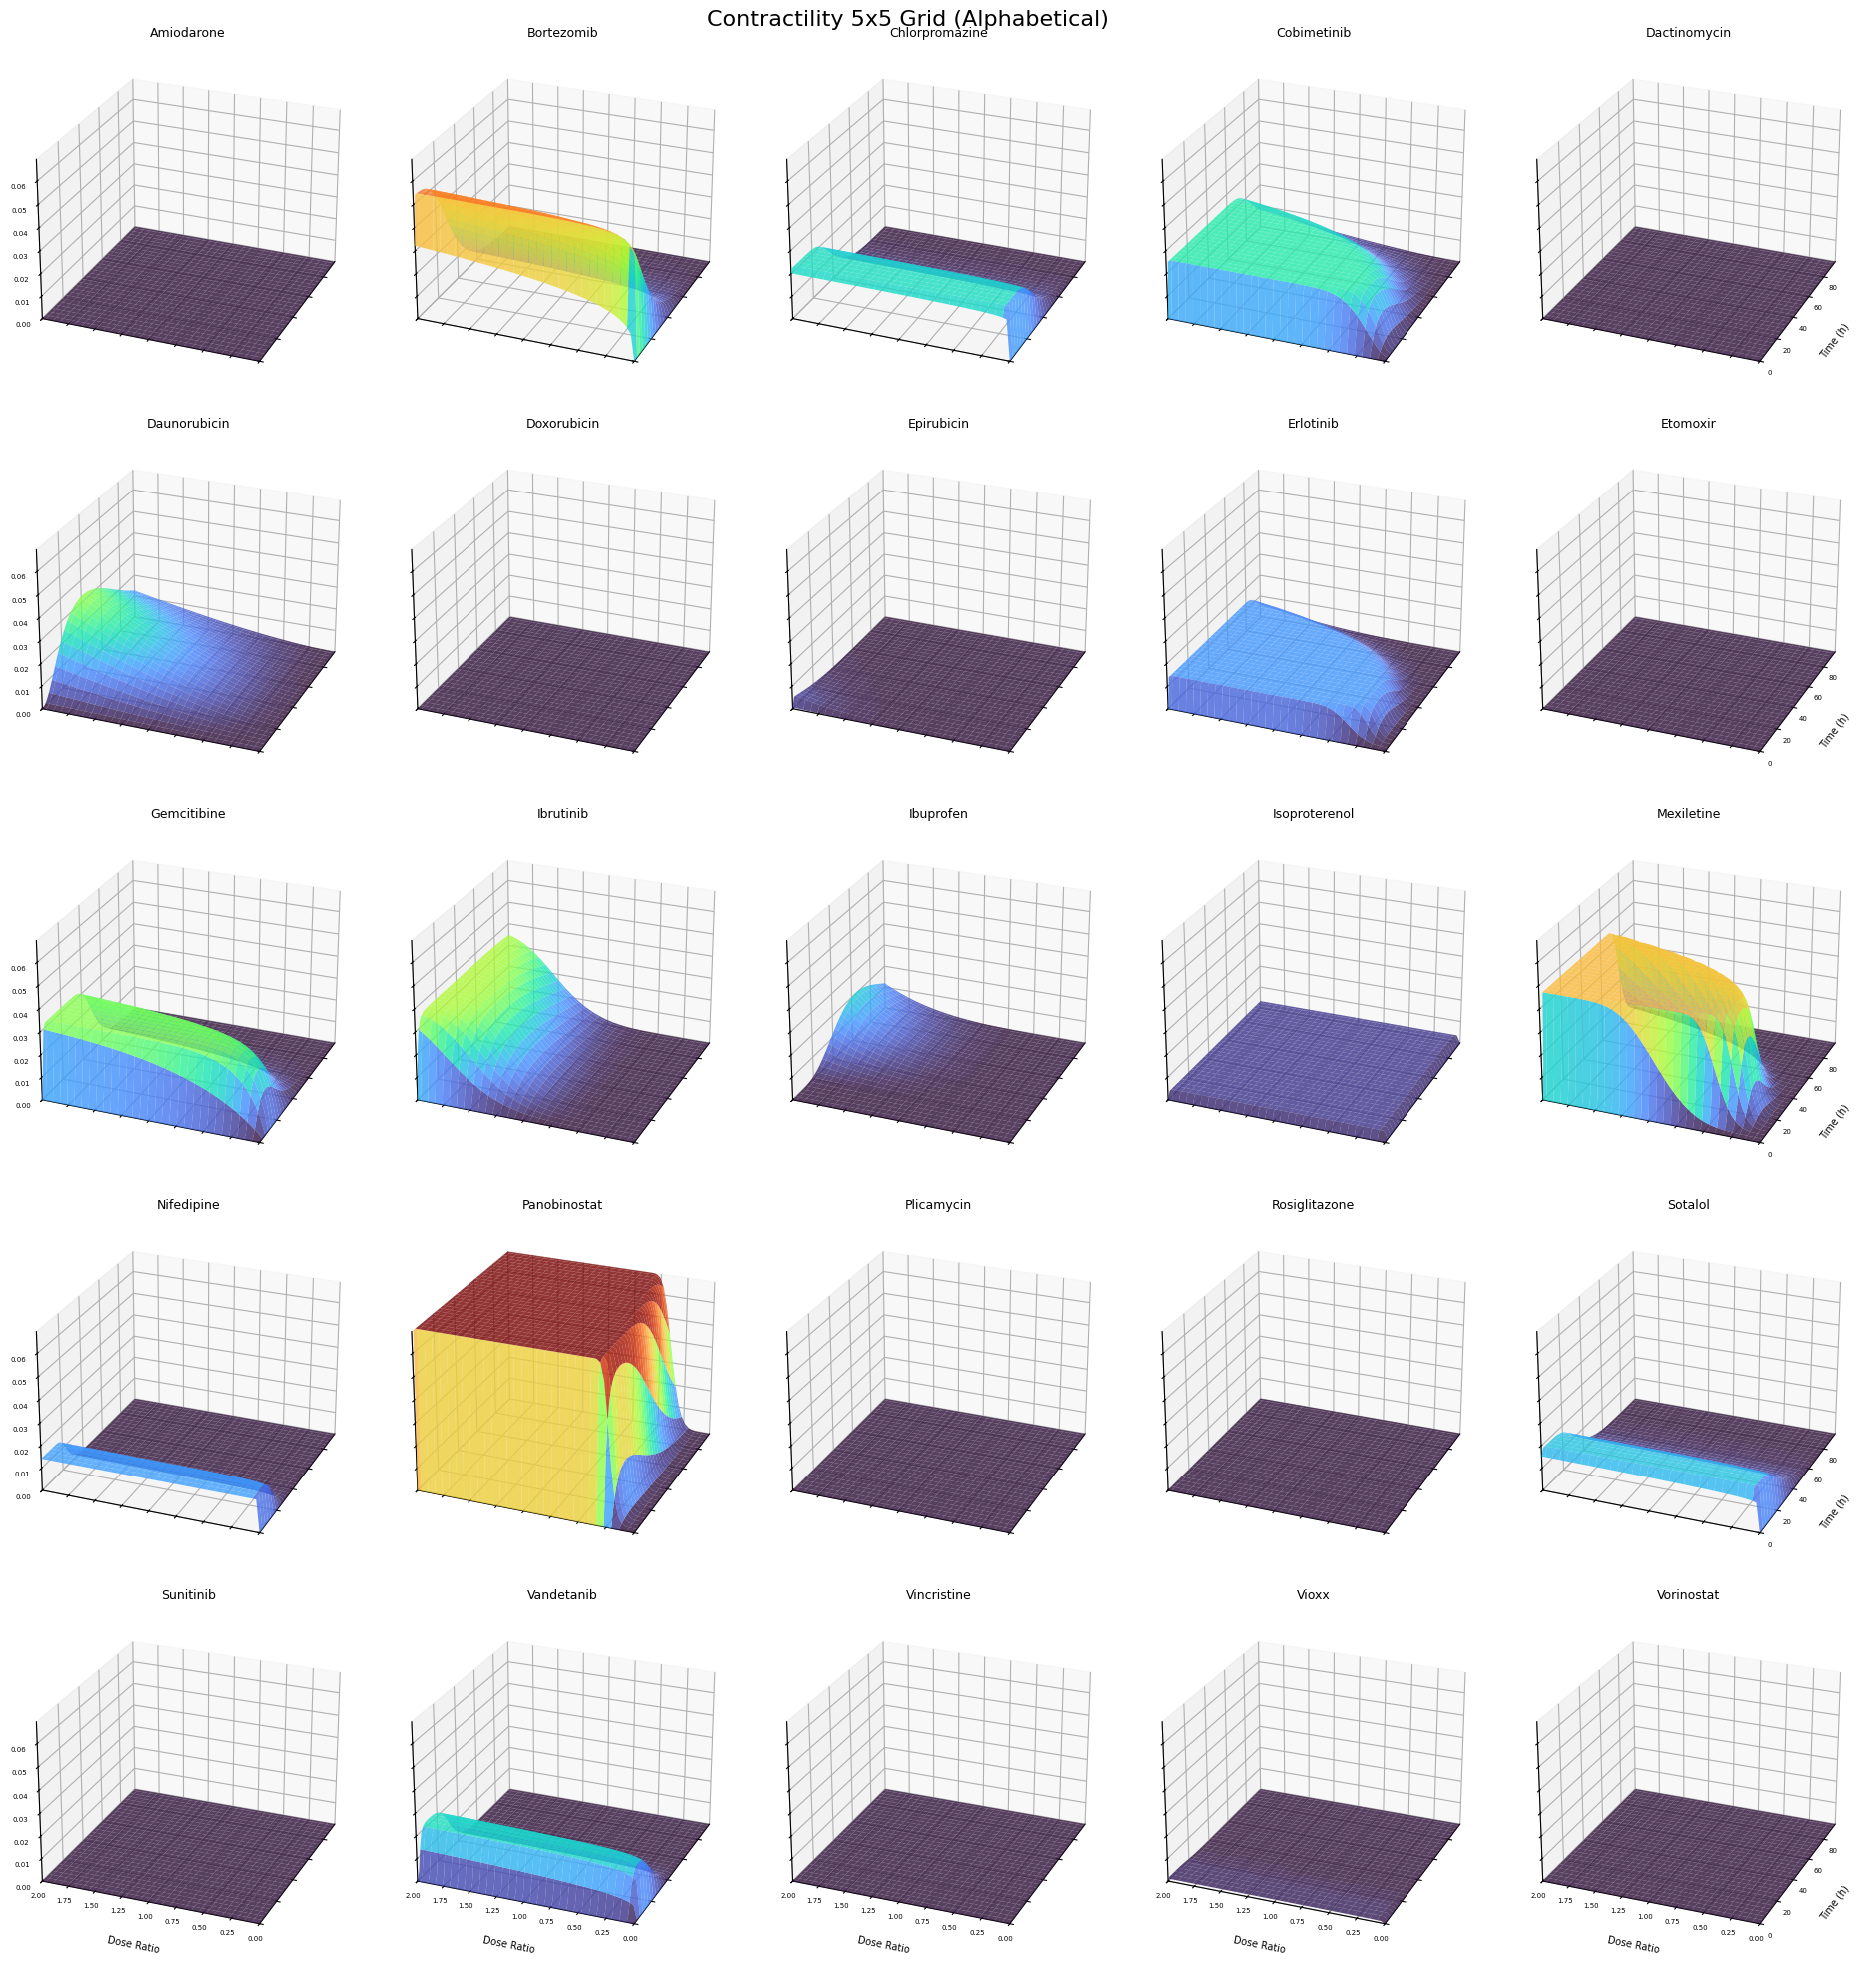

Both grids displayed with consistent global color scaling!


In [12]:
# Cell 16 - Display 5x5 Grids (O2 and Contractility)
# Dependencies: 1-8
# Purpose: Visualize both grids with GLOBAL color normalization

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

def configure_axes_display(ax, row, col, T, Dr, Response, zlim, vmin, vmax, response_type):
    """Configure axes for display grid with GLOBAL color normalization."""
    # CRITICAL: Use global color normalization for consistent colors
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    surf = ax.plot_surface(T, Dr, Response, cmap='turbo', norm=norm, alpha=0.8,
                          linewidth=0, antialiased=True, edgecolor='none')
    ax.view_init(elev=25, azim=-158)
    ax.set_xlim(0, 96)
    ax.set_ylim(0, 2)
    ax.set_zlim(zlim[0], zlim[1])
    ax.grid(True, alpha=0.3)

    is_left = (col == 0)
    is_right = (col == 4)
    is_bottom = (row == 4)

    show_x = is_right
    show_y = is_bottom
    show_z = is_left

    if show_x:
        ax.set_xlabel('Time (h)', fontsize=7, labelpad=1)
        ax.tick_params(axis='x', labelsize=5, pad=-2)
    else:
        ax.set_xlabel('')
        ax.set_xticklabels([])

    if show_y:
        ax.set_ylabel('Dose Ratio', fontsize=7, labelpad=1)
        ax.tick_params(axis='y', labelsize=5, pad=-2)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])

    if show_z:
        z_label = 'O2 (%)' if response_type == 'O2' else 'Contractility'
        ax.set_zlabel(z_label, fontsize=7, labelpad=0)
        ax.tick_params(axis='z', labelsize=5, pad=0)
    else:
        ax.set_zlabel('')
        ax.set_zticklabels([])

    return surf

print("Displaying 5x5 grids with GLOBAL color normalization...")
print("=" * 80)
print(f"O2 color scale: [0, {o2_vmax:.2f}]")
print(f"Contractility color scale: [0, {contractility_vmax:.4f}]")
print("=" * 80)

# O2 Grid
print("Creating O2 grid...")
sorted_drugs_o2 = df_o2_valid.sort_values('Drug').copy()
if len(sorted_drugs_o2) >= 25:
    sorted_drugs_o2 = sorted_drugs_o2.head(25)

fig_o2 = plt.figure(figsize=(20, 20))
fig_o2.suptitle('O2 5x5 Grid (Alphabetical)', fontsize=16, y=0.995)

dose_ratio = np.linspace(0, 2, 60)
time = np.linspace(0, 96, 60)
T, Dr = np.meshgrid(time, dose_ratio)

for i, (idx, row_data) in enumerate(sorted_drugs_o2.iterrows()):
    if i >= 25:
        break

    grid_row = i // 5
    grid_col = i % 5
    subplot_idx = i + 1

    drug_name = str(row_data['Drug'])
    R0 = row_data['R0']
    Emax = row_data['Emax']
    kappa = row_data['kappa']
    n = row_data['n']
    m = row_data['m']
    tau = row_data['tau']
    k_elim = row_data['k_elim']

    Response = pkpd_elimination_response(Dr, T, R0, Emax, kappa, n, m, tau, k_elim)
    Response = Response - R0
    Response = np.clip(Response, 0, o2_zmax)

    ax = fig_o2.add_subplot(5, 5, subplot_idx, projection='3d')
    configure_axes_display(ax, grid_row, grid_col, T, Dr, Response, 
                          (o2_zmin, o2_zmax), 0, o2_vmax, 'O2')
    ax.set_title(drug_name, fontsize=9, pad=2)

plt.subplots_adjust(left=0.05, right=0.98, top=0.98, bottom=0.02, wspace=0.05, hspace=0.1)
plt.show()

# Contractility Grid
print("Creating Contractility grid...")
sorted_drugs_con = df_contractility_valid.sort_values('Drug').copy()
if len(sorted_drugs_con) >= 25:
    sorted_drugs_con = sorted_drugs_con.head(25)

fig_con = plt.figure(figsize=(20, 20))
fig_con.suptitle('Contractility 5x5 Grid (Alphabetical)', fontsize=16, y=0.995)

for i, (idx, row_data) in enumerate(sorted_drugs_con.iterrows()):
    if i >= 25:
        break

    grid_row = i // 5
    grid_col = i % 5
    subplot_idx = i + 1

    drug_name = str(row_data['Drug'])
    R0 = row_data['R0']
    Emax = row_data['Emax']
    kappa = row_data['kappa']
    n = row_data['n']
    m = row_data['m']
    tau = row_data['tau']
    k_elim = row_data['k_elim']

    Response = pkpd_elimination_response(Dr, T, R0, Emax, kappa, n, m, tau, k_elim)
    Response = Response - R0
    Response = np.clip(Response, 0, contractility_zmax)

    ax = fig_con.add_subplot(5, 5, subplot_idx, projection='3d')
    configure_axes_display(ax, grid_row, grid_col, T, Dr, Response,
                          (contractility_zmin, contractility_zmax), 0, contractility_vmax, 
                          'Contractility')
    ax.set_title(drug_name, fontsize=9, pad=2)

plt.subplots_adjust(left=0.05, right=0.98, top=0.98, bottom=0.02, wspace=0.05, hspace=0.1)
plt.show()

print("Both grids displayed with consistent global color scaling!")


### Save the plots

In [25]:
# Cell 14 - 5x5 Grid of O2 Plots (Alphabetical Order)
# Dependencies: 1-8
# Layout: Left column=Z, Right column=X(Time), Bottom row=Y(Dose), Corners=both

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

def configure_axes_o2(ax, row, col, T, Dr, Response):
    """Configure axes based on grid position (5x5 grid) with GLOBAL color normalization."""
    # CRITICAL: Use global color normalization so all plots have same color scale
    norm = Normalize(vmin=0, vmax=o2_vmax)
    
    surf = ax.plot_surface(T, Dr, Response, cmap='turbo', norm=norm, alpha=0.8,
                          linewidth=0, antialiased=True, edgecolor='none')
    ax.view_init(elev=25, azim=-158)
    ax.set_xlim(0, 96)
    ax.set_ylim(0, 2)
    ax.set_zlim(o2_zmin, o2_zmax)
    ax.grid(True, alpha=0.3)

    is_left = (col == 0)
    is_right = (col == 4)
    is_bottom = (row == 4)

    show_x = is_right
    show_y = is_bottom
    show_z = is_left

    if show_x:
        ax.set_xlabel('Time (h)', fontsize=14, labelpad=5)
        ax.tick_params(axis='x', labelsize=11, pad=-1)
    else:
        ax.set_xlabel('')
        ax.set_xticklabels([])

    if show_y:
        ax.set_ylabel('Dose Ratio', fontsize=14, labelpad=5)
        ax.tick_params(axis='y', labelsize=11, pad=-1)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])

    if show_z:
        ax.set_zlabel('O2 (%)', fontsize=14, labelpad=1)
        ax.tick_params(axis='z', labelsize=11, pad=1)
    else:
        ax.set_zlabel('')
        ax.set_zticklabels([])

    return surf

print("Creating 5x5 O2 grid - saving individual plots with GLOBAL color normalization...")
print("=" * 80)

sorted_drugs = df_o2_valid.sort_values('Drug').copy()

if len(sorted_drugs) >= 25:
    sorted_drugs = sorted_drugs.head(25)

# Create output directory
o2_grid_dir = OUTPUT_DIR / "O2_5x5_Grid"
o2_grid_dir.mkdir(parents=True, exist_ok=True)

dose_ratio = np.linspace(0, 2, 60)
time = np.linspace(0, 96, 60)
T, Dr = np.meshgrid(time, dose_ratio)

for i, (idx, row_data) in enumerate(sorted_drugs.iterrows()):
    if i >= 25:
        break

    grid_row = i // 5
    grid_col = i % 5

    drug_name = str(row_data['Drug'])
    R0 = row_data['R0']
    Emax = row_data['Emax']
    kappa = row_data['kappa']
    n = row_data['n']
    m = row_data['m']
    tau = row_data['tau']
    k_elim = row_data['k_elim']

    Response = pkpd_elimination_response(Dr, T, R0, Emax, kappa, n, m, tau, k_elim)
    Response = Response - R0
    Response = np.clip(Response, 0, o2_zmax)

    # Create individual figure for each drug
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    configure_axes_o2(ax, grid_row, grid_col, T, Dr, Response)

    plt.tight_layout()

    # Save individual plot
    safe_name = drug_name.replace(' ', '_').replace('/', '_')
    safe_name = ''.join(c for c in safe_name if c.isalnum() or c in ('_', '-'))
    output_filename = f"{safe_name}_O2_5x5.png"
    output_path = o2_grid_dir / output_filename

    fig.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
    plt.close(fig)

    if (i + 1) % 5 == 0:
        print(f"Saved {i + 1}/25 plots")

print("")
print("All O2 individual plots saved to: " + str(o2_grid_dir))
print(f"Color scale: [0, {o2_vmax:.2f}] - CONSISTENT across all plots")


Creating 5x5 O2 grid - saving individual plots...
Drugs in order: ['Amiodarone', 'Bortezomib', 'Chlorpromazine', 'Cobimetinib', 'Dactinomycin', 'Daunorubicin', 'Doxorubicin', 'Epirubicin', 'Erlotinib', 'Etomoxir', 'Gemcitibine', 'Ibrutinib', 'Ibuprofen', 'Isoproterenol', 'Mexiletine', 'Nifedipine', 'Panobinostat', 'Plicamycin', 'Rosiglitazone', 'Sotalol', 'Sunitinib', 'Vandetanib', 'Vincristine', 'Vioxx', 'Vorinostat']
Saved: Amiodarone (row=0, col=0)
Saved: Bortezomib (row=0, col=1)
Saved: Chlorpromazine (row=0, col=2)
Saved: Cobimetinib (row=0, col=3)
Saved: Dactinomycin (row=0, col=4)
Saved: Daunorubicin (row=1, col=0)
Saved: Doxorubicin (row=1, col=1)
Saved: Epirubicin (row=1, col=2)
Saved: Erlotinib (row=1, col=3)
Saved: Etomoxir (row=1, col=4)
Saved: Gemcitibine (row=2, col=0)
Saved: Ibrutinib (row=2, col=1)
Saved: Ibuprofen (row=2, col=2)
Saved: Isoproterenol (row=2, col=3)
Saved: Mexiletine (row=2, col=4)
Saved: Nifedipine (row=3, col=0)
Saved: Panobinostat (row=3, col=1)
Saved

In [26]:
# Cell 15 - 5x5 Grid of Contractility Plots (Alphabetical Order)
# Dependencies: 1-8
# Layout: Left column=Z, Right column=X(Time), Bottom row=Y(Dose), Corners=both

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

def configure_axes_contractility(ax, row, col, T, Dr, Response):
    """Configure axes based on grid position (5x5 grid) with GLOBAL color normalization."""
    # CRITICAL: Use global color normalization so all plots have same color scale
    norm = Normalize(vmin=0, vmax=contractility_vmax)
    
    surf = ax.plot_surface(T, Dr, Response, cmap='turbo', norm=norm, alpha=0.8,
                          linewidth=0, antialiased=True, edgecolor='none')
    ax.view_init(elev=25, azim=-158)
    ax.set_xlim(0, 96)
    ax.set_ylim(0, 2)
    ax.set_zlim(contractility_zmin, contractility_zmax)
    ax.grid(True, alpha=0.3)

    is_left = (col == 0)
    is_right = (col == 4)
    is_bottom = (row == 4)

    show_x = is_right
    show_y = is_bottom
    show_z = is_left

    if show_x:
        ax.set_xlabel('Time (h)', fontsize=14, labelpad=5)
        ax.tick_params(axis='x', labelsize=11, pad=-1)
    else:
        ax.set_xlabel('')
        ax.set_xticklabels([])

    if show_y:
        ax.set_ylabel('Dose Ratio', fontsize=14, labelpad=5)
        ax.tick_params(axis='y', labelsize=11, pad=-1)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])

    if show_z:
        ax.set_zlabel('Contractility', fontsize=14, labelpad=1)
        ax.tick_params(axis='z', labelsize=11, pad=1)
    else:
        ax.set_zlabel('')
        ax.set_zticklabels([])

    return surf

print("Creating 5x5 Contractility grid - saving individual plots with GLOBAL color normalization...")
print("=" * 80)

sorted_drugs_con = df_contractility_valid.sort_values('Drug').copy()

if len(sorted_drugs_con) >= 25:
    sorted_drugs_con = sorted_drugs_con.head(25)

# Create output directory
contractility_grid_dir = OUTPUT_DIR / "Contractility_5x5_Grid"
contractility_grid_dir.mkdir(parents=True, exist_ok=True)

dose_ratio = np.linspace(0, 2, 60)
time = np.linspace(0, 96, 60)
T, Dr = np.meshgrid(time, dose_ratio)

for i, (idx, row_data) in enumerate(sorted_drugs_con.iterrows()):
    if i >= 25:
        break

    grid_row = i // 5
    grid_col = i % 5

    drug_name = str(row_data['Drug'])
    R0 = row_data['R0']
    Emax = row_data['Emax']
    kappa = row_data['kappa']
    n = row_data['n']
    m = row_data['m']
    tau = row_data['tau']
    k_elim = row_data['k_elim']

    Response = pkpd_elimination_response(Dr, T, R0, Emax, kappa, n, m, tau, k_elim)
    Response = Response - R0
    Response = np.clip(Response, 0, contractility_zmax)

    # Create individual figure for each drug
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    configure_axes_contractility(ax, grid_row, grid_col, T, Dr, Response)

    plt.tight_layout()

    # Save individual plot
    safe_name = drug_name.replace(' ', '_').replace('/', '_')
    safe_name = ''.join(c for c in safe_name if c.isalnum() or c in ('_', '-'))
    output_filename = f"{safe_name}_Contractility_5x5.png"
    output_path = contractility_grid_dir / output_filename

    fig.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
    plt.close(fig)

    if (i + 1) % 5 == 0:
        print(f"Saved {i + 1}/25 plots")

print("")
print("All Contractility individual plots saved to: " + str(contractility_grid_dir))
print(f"Color scale: [0, {contractility_vmax:.4f}] - CONSISTENT across all plots")


Creating 5x5 Contractility grid - saving individual plots...
Drugs in order: ['Amiodarone', 'Bortezomib', 'Chlorpromazine', 'Cobimetinib', 'Dactinomycin', 'Daunorubicin', 'Doxorubicin', 'Epirubicin', 'Erlotinib', 'Etomoxir', 'Gemcitibine', 'Ibrutinib', 'Ibuprofen', 'Isoproterenol', 'Mexiletine', 'Nifedipine', 'Panobinostat', 'Plicamycin', 'Rosiglitazone', 'Sotalol', 'Sunitinib', 'Vandetanib', 'Vincristine', 'Vioxx', 'Vorinostat']
Saved: Amiodarone (row=0, col=0)
Saved: Bortezomib (row=0, col=1)
Saved: Chlorpromazine (row=0, col=2)
Saved: Cobimetinib (row=0, col=3)
Saved: Dactinomycin (row=0, col=4)
Saved: Daunorubicin (row=1, col=0)
Saved: Doxorubicin (row=1, col=1)
Saved: Epirubicin (row=1, col=2)
Saved: Erlotinib (row=1, col=3)
Saved: Etomoxir (row=1, col=4)
Saved: Gemcitibine (row=2, col=0)
Saved: Ibrutinib (row=2, col=1)
Saved: Ibuprofen (row=2, col=2)
Saved: Isoproterenol (row=2, col=3)
Saved: Mexiletine (row=2, col=4)
Saved: Nifedipine (row=3, col=0)
Saved: Panobinostat (row=3, c